Note: In guideline it was mentioned to, reproduce one baseline (e.g., plain GCN or GraphSAGE) end-to-end on Dataset A. But we need to build the graph to use on GCN or GraphSAGE, so we, built the graph at 1_1_phase_graph_build.ipynb and then used that in this notebook

### GCN Baseline

GCN – Binary Graph Classification (Attack vs Benign) with Weighted BCE

In [1]:
import os
import pickle
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = "GothamDataset2025/processed_features/gotham_graphs"
BATCH_SIZE = 16          # increased for more graphs
LEARNING_RATE = 5e-4     # slightly higher
WEIGHT_DECAY = 1e-4
EPOCHS = 200
PATIENCE = 20
HIDDEN_DIM =  128
NUM_LAYERS = 3
DROPOUT = 0.2
LR_STEP = 30
LR_GAMMA = 0.5

# ---- LOAD DATA & NORMALISE ----
def load_graphs(split):
    with open(os.path.join(DATA_DIR, f"{split}_graphs.pkl"), 'rb') as f:
        return pickle.load(f)

with open(os.path.join(DATA_DIR, "norm_stats.json"), 'r') as f:
    norm_stats = json.load(f)

node_mean = torch.tensor(norm_stats["node_mean"], dtype=torch.float)
node_std  = torch.tensor(norm_stats["node_std"], dtype=torch.float)
node_dim  = norm_stats["node_dim"]

def normalise_graphs(graphs):
    for g in graphs:
        g.x = (g.x - node_mean) / (node_std + 1e-8)
        g.x = torch.clamp(g.x, -10, 10)

train_graphs = load_graphs('train')
val_graphs   = load_graphs('val')
test_graphs  = load_graphs('test')
print(f"Train: {len(train_graphs)}, Val: {len(val_graphs)}, Test: {len(test_graphs)}")

normalise_graphs(train_graphs)
normalise_graphs(val_graphs)
normalise_graphs(test_graphs)

# ---- BINARY LABELS (use g.y) ----
for g in train_graphs:
    g.y = g.y.float().unsqueeze(1)   # shape (1,1) for binary BCE
for g in val_graphs:
    g.y = g.y.float().unsqueeze(1)
for g in test_graphs:
    g.y = g.y.float().unsqueeze(1)

pos_count = sum(g.y.item() for g in train_graphs)
neg_count = len(train_graphs) - pos_count
pos_weight = torch.tensor([neg_count / (pos_count + 1e-6)]).to(DEVICE)
print(f"Positive graphs: {pos_count}, Negative: {neg_count}, pos_weight: {pos_weight.item():.2f}")

train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_graphs, batch_size=BATCH_SIZE, shuffle=False)

# ---- GCN MODEL (Binary output) ----
class GCNBinary(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_layers, dropout):
        super(GCNBinary, self).__init__()
        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(in_channels, hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
        self.convs.append(GCNConv(hidden_channels, hidden_channels))
        self.bns = nn.ModuleList([nn.BatchNorm1d(hidden_channels) for _ in range(num_layers)])
        self.dropout = dropout
        self.lin = nn.Linear(hidden_channels, 1)

    def forward(self, x, edge_index, batch):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = global_mean_pool(x, batch)
        x = self.lin(x)
        return x

model = GCNBinary(
    in_channels=node_dim,
    hidden_channels=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP, gamma=LR_GAMMA)

best_val_loss = float('inf')
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(DEVICE)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    avg_loss = total_loss / len(train_loader.dataset)

    model.eval()
    val_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for data in val_loader:
            data = data.to(DEVICE)
            out = model(data.x, data.edge_index, data.batch)
            loss = criterion(out, data.y)
            val_loss += loss.item() * data.num_graphs
            pred = torch.sigmoid(out).round().cpu().numpy()
            all_preds.extend(pred)
            all_labels.extend(data.y.cpu().numpy())
    val_loss /= len(val_loader.dataset)
    val_f1 = f1_score(all_labels, all_preds, zero_division=0)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch:03d} | LR: {current_lr:.6f} | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(DATA_DIR, "gcn_binary_best.pth"))
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

# ---- EVALUATION ON TEST SET ----
model.load_state_dict(torch.load(os.path.join(DATA_DIR, "gcn_binary_best.pth")))
model.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for data in test_loader:
        data = data.to(DEVICE)
        out = model(data.x, data.edge_index, data.batch)
        pred = torch.sigmoid(out).round().cpu().numpy()
        all_preds.extend(pred)
        all_labels.extend(data.y.cpu().numpy())

all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

acc = accuracy_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds, zero_division=0)
prec = precision_score(all_labels, all_preds, zero_division=0)
f1 = f1_score(all_labels, all_preds, zero_division=0)
try:
    auc = roc_auc_score(all_labels, all_preds)
except:
    auc = 0.0

print("\n========== Binary GCN Results ==========")
print(f"Accuracy:  {acc:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"Precision: {prec:.4f}")
print(f"F1:        {f1:.4f}")
print(f"AUC:       {auc:.4f}")
print("=========================================")

results = {
    "model": "GCN_binary",
    "accuracy": acc,
    "recall": rec,
    "precision": prec,
    "f1": f1,
    "auc": auc
}
with open(os.path.join(DATA_DIR, "gcn_binary_results.json"), "w") as f:
    json.dump(results, f, indent=4)
print("Results saved to gcn_binary_results.json")

Train: 932, Val: 200, Test: 200
Positive graphs: 316.0, Negative: 616.0, pos_weight: 1.95
Epoch 001 | LR: 0.000500 | Train Loss: 0.5681 | Val Loss: 1.0563 | Val F1: 0.2286
Epoch 002 | LR: 0.000500 | Train Loss: 0.3296 | Val Loss: 1.3727 | Val F1: 0.3467
Epoch 003 | LR: 0.000500 | Train Loss: 0.2652 | Val Loss: 4.1954 | Val F1: 0.3576
Epoch 004 | LR: 0.000500 | Train Loss: 0.1883 | Val Loss: 7.0643 | Val F1: 0.3576
Epoch 005 | LR: 0.000500 | Train Loss: 0.1829 | Val Loss: 4.8676 | Val F1: 0.4970
Epoch 006 | LR: 0.000500 | Train Loss: 0.1904 | Val Loss: 2.8336 | Val F1: 0.5150
Epoch 007 | LR: 0.000500 | Train Loss: 0.1449 | Val Loss: 2.8113 | Val F1: 0.8929
Epoch 008 | LR: 0.000500 | Train Loss: 0.1275 | Val Loss: 1.5010 | Val F1: 0.9412
Epoch 009 | LR: 0.000500 | Train Loss: 0.1804 | Val Loss: 3.2831 | Val F1: 0.8571
Epoch 010 | LR: 0.000500 | Train Loss: 0.1393 | Val Loss: 2.7830 | Val F1: 0.5325
Epoch 011 | LR: 0.000500 | Train Loss: 0.1478 | Val Loss: 2.0893 | Val F1: 0.5989
Epoch 01

GCN – Multi‑Label Graph Classification (with per‑class weighted BCE)

In [2]:
import os
import pickle
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = "GothamDataset2025/processed_features/gotham_graphs"
BATCH_SIZE = 16
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-4
EPOCHS = 200
PATIENCE = 20
HIDDEN_DIM = 128
NUM_LAYERS = 3
DROPOUT = 0.2
LR_STEP = 30
LR_GAMMA = 0.5

# ---- LOAD & NORMALISE ----
def load_graphs(split):
    with open(os.path.join(DATA_DIR, f"{split}_graphs.pkl"), 'rb') as f:
        return pickle.load(f)

with open(os.path.join(DATA_DIR, "norm_stats.json"), 'r') as f:
    norm_stats = json.load(f)

node_mean = torch.tensor(norm_stats["node_mean"], dtype=torch.float)
node_std  = torch.tensor(norm_stats["node_std"], dtype=torch.float)
node_dim  = norm_stats["node_dim"]

def normalise_graphs(graphs):
    for g in graphs:
        g.x = (g.x - node_mean) / (node_std + 1e-8)
        g.x = torch.clamp(g.x, -10, 10)

train_graphs = load_graphs('train')
val_graphs   = load_graphs('val')
test_graphs  = load_graphs('test')
print(f"Train: {len(train_graphs)}, Val: {len(val_graphs)}, Test: {len(test_graphs)}")

normalise_graphs(train_graphs)
normalise_graphs(val_graphs)
normalise_graphs(test_graphs)

# ---- BUILD MULTI-HOT LABELS ----
attack_names = set()
for g in train_graphs:
    for name in g.edge_attack_names:
        if name != 'Benign':
            attack_names.add(name)
attack_names = sorted(list(attack_names))
num_classes = len(attack_names)
print(f"Number of attack classes: {num_classes}")
print("Classes:", attack_names)

class_to_idx = {name: i for i, name in enumerate(attack_names)}

def get_multihot_labels(graph):
    labels = torch.zeros(num_classes, dtype=torch.float)
    for name in graph.edge_attack_names:
        if name != 'Benign' and name in class_to_idx:
            labels[class_to_idx[name]] = 1.0
    return labels.unsqueeze(0)

for g in train_graphs:
    g.y_multihot = get_multihot_labels(g)
for g in val_graphs:
    g.y_multihot = get_multihot_labels(g)
for g in test_graphs:
    g.y_multihot = get_multihot_labels(g)

# ---- Focal Loss for multi‑label (optional) ----
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        p = torch.sigmoid(inputs)
        pt = p * targets + (1 - p) * (1 - targets)
        focal_weight = (1 - pt) ** self.gamma
        if self.alpha is not None:
            alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            focal_weight = focal_weight * alpha_t
        loss = focal_weight * bce_loss
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss

# Compute per‑class pos_weight for BCE (or use focal loss with alpha)
pos_counts = torch.stack([g.y_multihot for g in train_graphs]).sum(0)
neg_counts = len(train_graphs) - pos_counts
pos_weight = neg_counts / (pos_counts + 1e-6)
print("Pos_weight per class:", pos_weight.tolist())

# Choose loss: uncomment one of the following
# criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE))  # weighted BCE
criterion = FocalLoss(gamma=2.0, alpha=pos_weight.to(DEVICE) / (pos_weight.to(DEVICE) + 1.0))  # focal with alpha

train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_graphs, batch_size=BATCH_SIZE, shuffle=False)

# ---- GCN MODEL (Multi‑label) ----
class GCNMulti(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers, dropout):
        super(GCNMulti, self).__init__()
        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(in_channels, hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
        self.convs.append(GCNConv(hidden_channels, hidden_channels))
        self.bns = nn.ModuleList([nn.BatchNorm1d(hidden_channels) for _ in range(num_layers)])
        self.dropout = dropout
        self.lin = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = global_mean_pool(x, batch)
        x = self.lin(x)
        return x

model = GCNMulti(
    in_channels=node_dim,
    hidden_channels=HIDDEN_DIM,
    out_channels=num_classes,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP, gamma=LR_GAMMA)

best_val_loss = float('inf')
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(DEVICE)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y_multihot)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    avg_loss = total_loss / len(train_loader.dataset)

    model.eval()
    val_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for data in val_loader:
            data = data.to(DEVICE)
            out = model(data.x, data.edge_index, data.batch)
            loss = criterion(out, data.y_multihot)
            val_loss += loss.item() * data.num_graphs
            preds = torch.sigmoid(out).cpu().numpy()
            labels = data.y_multihot.cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels)
    val_loss /= len(val_loader.dataset)

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    pred_binary = (all_preds >= 0.5).astype(int)
    macro_f1 = f1_score(all_labels, pred_binary, average='macro', zero_division=0)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch:03d} | LR: {current_lr:.6f} | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f} | Val Macro F1: {macro_f1:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(DATA_DIR, "gcn_multilabel_best.pth"))
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

# ---- EVALUATION ----
model.load_state_dict(torch.load(os.path.join(DATA_DIR, "gcn_multilabel_best.pth")))
model.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for data in test_loader:
        data = data.to(DEVICE)
        out = model(data.x, data.edge_index, data.batch)
        preds = torch.sigmoid(out).cpu().numpy()
        labels = data.y_multihot.cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)
pred_binary = (all_preds >= 0.5).astype(int)

per_class_recall = recall_score(all_labels, pred_binary, average=None, zero_division=0)
per_class_precision = precision_score(all_labels, pred_binary, average=None, zero_division=0)
per_class_f1 = f1_score(all_labels, pred_binary, average=None, zero_division=0)

macro_f1 = f1_score(all_labels, pred_binary, average='macro', zero_division=0)
macro_recall = recall_score(all_labels, pred_binary, average='macro', zero_division=0)
macro_precision = precision_score(all_labels, pred_binary, average='macro', zero_division=0)

pr_auc_per_class = []
for i in range(num_classes):
    if np.sum(all_labels[:, i]) > 0:
        try:
            auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
        except:
            auc = 0.0
    else:
        auc = 0.0
    pr_auc_per_class.append(auc)
macro_pr_auc = np.mean(pr_auc_per_class)

print("\n========== Multi‑Label GCN Results ==========")
print(f"Macro F1:        {macro_f1:.4f}")
print(f"Macro Recall:    {macro_recall:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro PR‑AUC:    {macro_pr_auc:.4f}")
print("\nPer‑class metrics:")
for i, name in enumerate(attack_names):
    print(f"  {name:20s} | Recall: {per_class_recall[i]:.4f} | Prec: {per_class_precision[i]:.4f} | F1: {per_class_f1[i]:.4f} | PR‑AUC: {pr_auc_per_class[i]:.4f}")
print("==============================================")

results = {
    "model": "GCN_multilabel",
    "loss": "FocalLoss" if isinstance(criterion, FocalLoss) else "BCEWithLogitsLoss",
    "macro_f1": macro_f1,
    "macro_recall": macro_recall,
    "macro_precision": macro_precision,
    "macro_pr_auc": macro_pr_auc,
    "per_class": {
        name: {"recall": per_class_recall[i], "precision": per_class_precision[i], "f1": per_class_f1[i], "pr_auc": pr_auc_per_class[i]}
        for i, name in enumerate(attack_names)
    }
}
with open(os.path.join(DATA_DIR, "gcn_multilabel_results.json"), "w") as f:
    json.dump(results, f, indent=4)
print("Results saved to gcn_multilabel_results.json")

Train: 932, Val: 200, Test: 200
Number of attack classes: 14
Classes: ['C&C Communication', 'CoAP Amplification', 'File Download', 'Ingress Tool Transfer', 'Merlin C&C Communication', 'Merlin ICMP Flooding', 'Merlin TCP Flooding', 'Merlin UDP Flooding', 'Mirai C&C Communication', 'Reporting', 'TCP Scan', 'Telnet Brute Force', 'UDP Scan', 'Unknown']
Pos_weight per class: [[22.897436141967773, 464.9997863769531, 102.5555419921875, 30.066665649414062, 5.563380241394043, 76.66666412353516, 65.57142639160156, 154.33331298828125, 33.518516540527344, 34.84614944458008, 22.897436141967773, 18.41666603088379, 11.94444465637207, 45.59999465942383]]
Epoch 001 | LR: 0.000500 | Train Loss: 0.0119 | Val Loss: 0.1163 | Val Macro F1: 0.0000
Epoch 002 | LR: 0.000500 | Train Loss: 0.0072 | Val Loss: 0.0996 | Val Macro F1: 0.0012
Epoch 003 | LR: 0.000500 | Train Loss: 0.0064 | Val Loss: 0.1034 | Val Macro F1: 0.0056
Epoch 004 | LR: 0.000500 | Train Loss: 0.0054 | Val Loss: 0.1481 | Val Macro F1: 0.0056
E

### GraphSAGE Baseline

GraphSAGE – Binary Graph Classification (Attack vs Benign) with Weighted BCE

In [3]:
import os
import pickle
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import DataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = "GothamDataset2025/processed_features/gotham_graphs"
BATCH_SIZE = 16
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-4
EPOCHS = 200
PATIENCE = 20
HIDDEN_DIM = 128
NUM_LAYERS = 3
DROPOUT = 0.2
LR_STEP = 30
LR_GAMMA = 0.5

# ---- LOAD & NORMALISE ----
def load_graphs(split):
    with open(os.path.join(DATA_DIR, f"{split}_graphs.pkl"), 'rb') as f:
        return pickle.load(f)

with open(os.path.join(DATA_DIR, "norm_stats.json"), 'r') as f:
    norm_stats = json.load(f)

node_mean = torch.tensor(norm_stats["node_mean"], dtype=torch.float)
node_std  = torch.tensor(norm_stats["node_std"], dtype=torch.float)
node_dim  = norm_stats["node_dim"]

def normalise_graphs(graphs):
    for g in graphs:
        g.x = (g.x - node_mean) / (node_std + 1e-8)
        g.x = torch.clamp(g.x, -10, 10)

train_graphs = load_graphs('train')
val_graphs   = load_graphs('val')
test_graphs  = load_graphs('test')
print(f"Train: {len(train_graphs)}, Val: {len(val_graphs)}, Test: {len(test_graphs)}")

normalise_graphs(train_graphs)
normalise_graphs(val_graphs)
normalise_graphs(test_graphs)

# ---- BINARY LABELS ----
for g in train_graphs:
    g.y = g.y.float().unsqueeze(1)
for g in val_graphs:
    g.y = g.y.float().unsqueeze(1)
for g in test_graphs:
    g.y = g.y.float().unsqueeze(1)

pos_count = sum(g.y.item() for g in train_graphs)
neg_count = len(train_graphs) - pos_count
pos_weight = torch.tensor([neg_count / (pos_count + 1e-6)]).to(DEVICE)
print(f"Positive graphs: {pos_count}, Negative: {neg_count}, pos_weight: {pos_weight.item():.2f}")

train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_graphs, batch_size=BATCH_SIZE, shuffle=False)

# ---- GraphSAGE MODEL (Binary) ----
class GraphSAGEBinary(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_layers, dropout):
        super(GraphSAGEBinary, self).__init__()
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        self.bns = nn.ModuleList([nn.BatchNorm1d(hidden_channels) for _ in range(num_layers)])
        self.dropout = dropout
        self.lin = nn.Linear(hidden_channels, 1)

    def forward(self, x, edge_index, batch):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = global_mean_pool(x, batch)
        x = self.lin(x)
        return x

model = GraphSAGEBinary(
    in_channels=node_dim,
    hidden_channels=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP, gamma=LR_GAMMA)

best_val_loss = float('inf')
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(DEVICE)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    avg_loss = total_loss / len(train_loader.dataset)

    model.eval()
    val_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for data in val_loader:
            data = data.to(DEVICE)
            out = model(data.x, data.edge_index, data.batch)
            loss = criterion(out, data.y)
            val_loss += loss.item() * data.num_graphs
            pred = torch.sigmoid(out).round().cpu().numpy()
            all_preds.extend(pred)
            all_labels.extend(data.y.cpu().numpy())
    val_loss /= len(val_loader.dataset)
    val_f1 = f1_score(all_labels, all_preds, zero_division=0)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch:03d} | LR: {current_lr:.6f} | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(DATA_DIR, "graphsage_binary_best.pth"))
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

# ---- EVALUATION ----
model.load_state_dict(torch.load(os.path.join(DATA_DIR, "graphsage_binary_best.pth")))
model.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for data in test_loader:
        data = data.to(DEVICE)
        out = model(data.x, data.edge_index, data.batch)
        pred = torch.sigmoid(out).round().cpu().numpy()
        all_preds.extend(pred)
        all_labels.extend(data.y.cpu().numpy())

all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

acc = accuracy_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds, zero_division=0)
prec = precision_score(all_labels, all_preds, zero_division=0)
f1 = f1_score(all_labels, all_preds, zero_division=0)
try:
    auc = roc_auc_score(all_labels, all_preds)
except:
    auc = 0.0

print("\n========== Binary GraphSAGE Results ==========")
print(f"Accuracy:  {acc:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"Precision: {prec:.4f}")
print(f"F1:        {f1:.4f}")
print(f"AUC:       {auc:.4f}")
print("===============================================")

results = {
    "model": "GraphSAGE_binary",
    "accuracy": acc,
    "recall": rec,
    "precision": prec,
    "f1": f1,
    "auc": auc
}
with open(os.path.join(DATA_DIR, "graphsage_binary_results.json"), "w") as f:
    json.dump(results, f, indent=4)
print("Results saved to graphsage_binary_results.json")

Train: 932, Val: 200, Test: 200
Positive graphs: 316.0, Negative: 616.0, pos_weight: 1.95
Epoch 001 | LR: 0.000500 | Train Loss: 0.6449 | Val Loss: 1.4316 | Val F1: 0.2535
Epoch 002 | LR: 0.000500 | Train Loss: 0.3394 | Val Loss: 0.7609 | Val F1: 0.8357
Epoch 003 | LR: 0.000500 | Train Loss: 0.2277 | Val Loss: 0.7509 | Val F1: 0.8879
Epoch 004 | LR: 0.000500 | Train Loss: 0.2556 | Val Loss: 0.6517 | Val F1: 0.9123
Epoch 005 | LR: 0.000500 | Train Loss: 0.2115 | Val Loss: 1.4816 | Val F1: 0.5412
Epoch 006 | LR: 0.000500 | Train Loss: 0.1562 | Val Loss: 0.8886 | Val F1: 0.8077
Epoch 007 | LR: 0.000500 | Train Loss: 0.1495 | Val Loss: 1.6147 | Val F1: 0.5665
Epoch 008 | LR: 0.000500 | Train Loss: 0.1534 | Val Loss: 1.3452 | Val F1: 0.5747
Epoch 009 | LR: 0.000500 | Train Loss: 0.2230 | Val Loss: 0.7623 | Val F1: 0.9123
Epoch 010 | LR: 0.000500 | Train Loss: 0.1508 | Val Loss: 1.8012 | Val F1: 0.5325
Epoch 011 | LR: 0.000500 | Train Loss: 0.2231 | Val Loss: 1.3810 | Val F1: 0.5581
Epoch 01

GraphSAGE – Multi‑Label Graph Classification (with per‑class weighted BCE)

In [4]:
import os
import pickle
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import DataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = "GothamDataset2025/processed_features/gotham_graphs"
BATCH_SIZE = 16
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-4
EPOCHS = 200
PATIENCE = 20
HIDDEN_DIM = 128
NUM_LAYERS = 3
DROPOUT = 0.2
LR_STEP = 30
LR_GAMMA = 0.5

# ---- LOAD & NORMALISE ----
def load_graphs(split):
    with open(os.path.join(DATA_DIR, f"{split}_graphs.pkl"), 'rb') as f:
        return pickle.load(f)

with open(os.path.join(DATA_DIR, "norm_stats.json"), 'r') as f:
    norm_stats = json.load(f)

node_mean = torch.tensor(norm_stats["node_mean"], dtype=torch.float)
node_std  = torch.tensor(norm_stats["node_std"], dtype=torch.float)
node_dim  = norm_stats["node_dim"]

def normalise_graphs(graphs):
    for g in graphs:
        g.x = (g.x - node_mean) / (node_std + 1e-8)
        g.x = torch.clamp(g.x, -10, 10)

train_graphs = load_graphs('train')
val_graphs   = load_graphs('val')
test_graphs  = load_graphs('test')
print(f"Train: {len(train_graphs)}, Val: {len(val_graphs)}, Test: {len(test_graphs)}")

normalise_graphs(train_graphs)
normalise_graphs(val_graphs)
normalise_graphs(test_graphs)

# ---- BUILD MULTI-HOT LABELS ----
attack_names = set()
for g in train_graphs:
    for name in g.edge_attack_names:
        if name != 'Benign':
            attack_names.add(name)
attack_names = sorted(list(attack_names))
num_classes = len(attack_names)
print(f"Number of attack classes: {num_classes}")
print("Classes:", attack_names)

class_to_idx = {name: i for i, name in enumerate(attack_names)}

def get_multihot_labels(graph):
    labels = torch.zeros(num_classes, dtype=torch.float)
    for name in graph.edge_attack_names:
        if name != 'Benign' and name in class_to_idx:
            labels[class_to_idx[name]] = 1.0
    return labels.unsqueeze(0)

for g in train_graphs:
    g.y_multihot = get_multihot_labels(g)
for g in val_graphs:
    g.y_multihot = get_multihot_labels(g)
for g in test_graphs:
    g.y_multihot = get_multihot_labels(g)

# ---- Focal Loss (optional) ----
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        p = torch.sigmoid(inputs)
        pt = p * targets + (1 - p) * (1 - targets)
        focal_weight = (1 - pt) ** self.gamma
        if self.alpha is not None:
            alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            focal_weight = focal_weight * alpha_t
        loss = focal_weight * bce_loss
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss

pos_counts = torch.stack([g.y_multihot for g in train_graphs]).sum(0)
neg_counts = len(train_graphs) - pos_counts
pos_weight = neg_counts / (pos_counts + 1e-6)
print("Pos_weight per class:", pos_weight.tolist())

# Choose loss
# criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE))
criterion = FocalLoss(gamma=2.0, alpha=pos_weight.to(DEVICE) / (pos_weight.to(DEVICE) + 1.0))

train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_graphs, batch_size=BATCH_SIZE, shuffle=False)

# ---- GraphSAGE MODEL (Multi‑label) ----
class GraphSAGEMulti(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers, dropout):
        super(GraphSAGEMulti, self).__init__()
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        self.bns = nn.ModuleList([nn.BatchNorm1d(hidden_channels) for _ in range(num_layers)])
        self.dropout = dropout
        self.lin = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = global_mean_pool(x, batch)
        x = self.lin(x)
        return x

model = GraphSAGEMulti(
    in_channels=node_dim,
    hidden_channels=HIDDEN_DIM,
    out_channels=num_classes,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP, gamma=LR_GAMMA)

best_val_loss = float('inf')
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(DEVICE)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y_multihot)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    avg_loss = total_loss / len(train_loader.dataset)

    model.eval()
    val_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for data in val_loader:
            data = data.to(DEVICE)
            out = model(data.x, data.edge_index, data.batch)
            loss = criterion(out, data.y_multihot)
            val_loss += loss.item() * data.num_graphs
            preds = torch.sigmoid(out).cpu().numpy()
            labels = data.y_multihot.cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels)
    val_loss /= len(val_loader.dataset)

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    pred_binary = (all_preds >= 0.5).astype(int)
    macro_f1 = f1_score(all_labels, pred_binary, average='macro', zero_division=0)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch:03d} | LR: {current_lr:.6f} | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f} | Val Macro F1: {macro_f1:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(DATA_DIR, "graphsage_multilabel_best.pth"))
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

# ---- EVALUATION ----
model.load_state_dict(torch.load(os.path.join(DATA_DIR, "graphsage_multilabel_best.pth")))
model.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for data in test_loader:
        data = data.to(DEVICE)
        out = model(data.x, data.edge_index, data.batch)
        preds = torch.sigmoid(out).cpu().numpy()
        labels = data.y_multihot.cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)
pred_binary = (all_preds >= 0.5).astype(int)

per_class_recall = recall_score(all_labels, pred_binary, average=None, zero_division=0)
per_class_precision = precision_score(all_labels, pred_binary, average=None, zero_division=0)
per_class_f1 = f1_score(all_labels, pred_binary, average=None, zero_division=0)

macro_f1 = f1_score(all_labels, pred_binary, average='macro', zero_division=0)
macro_recall = recall_score(all_labels, pred_binary, average='macro', zero_division=0)
macro_precision = precision_score(all_labels, pred_binary, average='macro', zero_division=0)

pr_auc_per_class = []
for i in range(num_classes):
    if np.sum(all_labels[:, i]) > 0:
        try:
            auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
        except:
            auc = 0.0
    else:
        auc = 0.0
    pr_auc_per_class.append(auc)
macro_pr_auc = np.mean(pr_auc_per_class)

print("\n========== Multi‑Label GraphSAGE Results ==========")
print(f"Macro F1:        {macro_f1:.4f}")
print(f"Macro Recall:    {macro_recall:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro PR‑AUC:    {macro_pr_auc:.4f}")
print("\nPer‑class metrics:")
for i, name in enumerate(attack_names):
    print(f"  {name:20s} | Recall: {per_class_recall[i]:.4f} | Prec: {per_class_precision[i]:.4f} | F1: {per_class_f1[i]:.4f} | PR‑AUC: {pr_auc_per_class[i]:.4f}")
print("====================================================")

results = {
    "model": "GraphSAGE_multilabel",
    "loss": "FocalLoss" if isinstance(criterion, FocalLoss) else "BCEWithLogitsLoss",
    "macro_f1": macro_f1,
    "macro_recall": macro_recall,
    "macro_precision": macro_precision,
    "macro_pr_auc": macro_pr_auc,
    "per_class": {
        name: {"recall": per_class_recall[i], "precision": per_class_precision[i], "f1": per_class_f1[i], "pr_auc": pr_auc_per_class[i]}
        for i, name in enumerate(attack_names)
    }
}
with open(os.path.join(DATA_DIR, "graphsage_multilabel_results.json"), "w") as f:
    json.dump(results, f, indent=4)
print("Results saved to graphsage_multilabel_results.json")

Train: 932, Val: 200, Test: 200
Number of attack classes: 14
Classes: ['C&C Communication', 'CoAP Amplification', 'File Download', 'Ingress Tool Transfer', 'Merlin C&C Communication', 'Merlin ICMP Flooding', 'Merlin TCP Flooding', 'Merlin UDP Flooding', 'Mirai C&C Communication', 'Reporting', 'TCP Scan', 'Telnet Brute Force', 'UDP Scan', 'Unknown']
Pos_weight per class: [[22.897436141967773, 464.9997863769531, 102.5555419921875, 30.066665649414062, 5.563380241394043, 76.66666412353516, 65.57142639160156, 154.33331298828125, 33.518516540527344, 34.84614944458008, 22.897436141967773, 18.41666603088379, 11.94444465637207, 45.59999465942383]]
Epoch 001 | LR: 0.000500 | Train Loss: 0.0102 | Val Loss: 0.0098 | Val Macro F1: 0.0443
Epoch 002 | LR: 0.000500 | Train Loss: 0.0069 | Val Loss: 0.0136 | Val Macro F1: 0.0451
Epoch 003 | LR: 0.000500 | Train Loss: 0.0055 | Val Loss: 0.0146 | Val Macro F1: 0.0443
Epoch 004 | LR: 0.000500 | Train Loss: 0.0044 | Val Loss: 0.0152 | Val Macro F1: 0.0443
E

In [5]:
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

DATA_DIR = "GothamDataset2025/processed_features/gotham_graphs"

# Load binary results
gcn_bin = json.load(open(os.path.join(DATA_DIR, "gcn_binary_results.json")))
sage_bin = json.load(open(os.path.join(DATA_DIR, "graphsage_binary_results.json")))

# Load multi‑label results
gcn_multi = json.load(open(os.path.join(DATA_DIR, "gcn_multilabel_results.json")))
sage_multi = json.load(open(os.path.join(DATA_DIR, "graphsage_multilabel_results.json")))

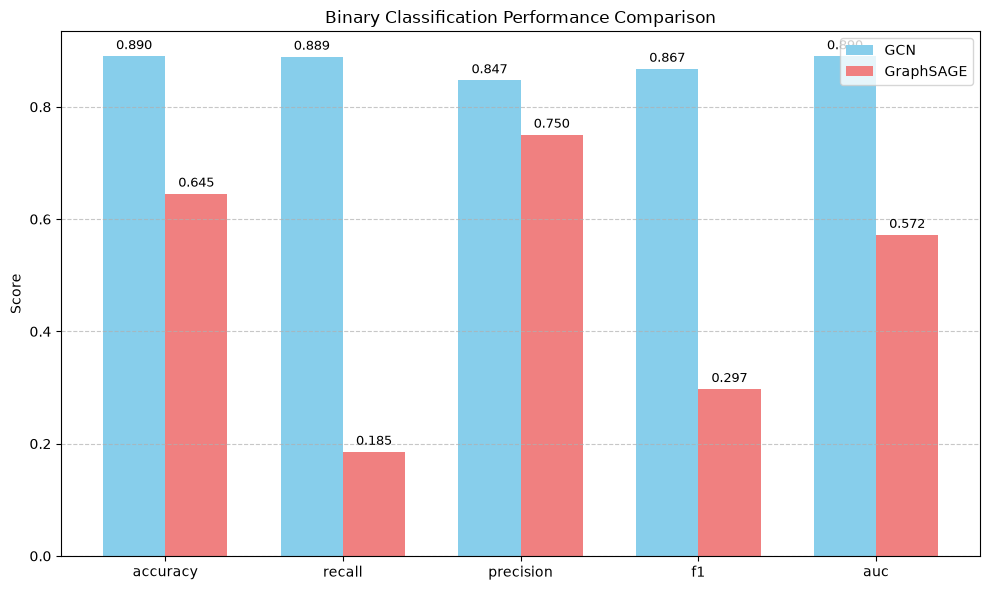

In [6]:
metrics = ['accuracy', 'recall', 'precision', 'f1', 'auc']
gcn_vals = [gcn_bin[m] for m in metrics]
sage_vals = [sage_bin[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, gcn_vals, width, label='GCN', color='skyblue')
bars2 = ax.bar(x + width/2, sage_vals, width, label='GraphSAGE', color='lightcoral')

ax.set_ylabel('Score')
ax.set_title('Binary Classification Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('binary_comparison.png', dpi=150)
plt.show()

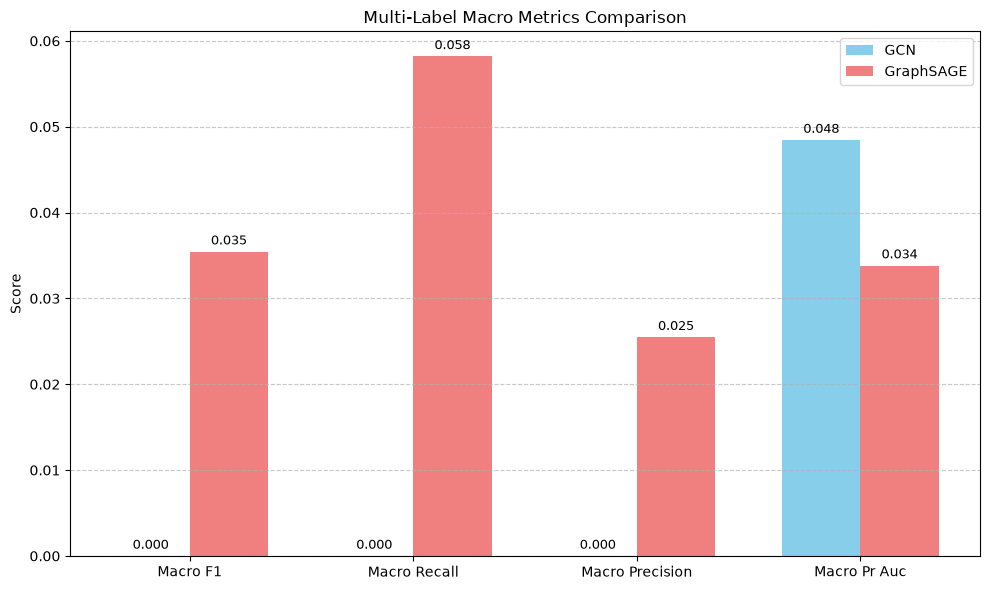

In [7]:
macro_metrics = ['macro_f1', 'macro_recall', 'macro_precision', 'macro_pr_auc']
gcn_macro = [gcn_multi[m] for m in macro_metrics]
sage_macro = [sage_multi[m] for m in macro_metrics]

x = np.arange(len(macro_metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, gcn_macro, width, label='GCN', color='skyblue')
bars2 = ax.bar(x + width/2, sage_macro, width, label='GraphSAGE', color='lightcoral')

ax.set_ylabel('Score')
ax.set_title('Multi‑Label Macro Metrics Comparison')
ax.set_xticks(x)
ax.set_xticklabels([m.replace('_', ' ').title() for m in macro_metrics])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('multilabel_macro_comparison.png', dpi=150)
plt.show()